# Gradient Descent from Scratch — CGPA Regression

This notebook implements batch gradient descent and mini-batch gradient descent for predicting CGPA from academic and co-curricular features.

## Cell 1 — Import required libraries
This cell imports NumPy, Pandas, Matplotlib, and scikit-learn so the practical can load data, train models, and plot results.

Expected output: a confirmation message that the libraries were imported successfully.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print('Libraries imported successfully.')

Libraries imported successfully.


In [19]:
placement = pd.read_csv('placement_predict_50k.csv')
print('Shape of dataset:', placement.shape)
placement.head()

Shape of dataset: (50000, 12)


,StudentID,Stream,Gender,CGPA,CGPA_Tier,Internships,Projects,AptitudeScore,SoftSkillsRating,Backlogs,PlacementTraining,PlacementStatus
0,1,CSE,Male,5.00,Low,0,0,37,2.3,3,No,NotPlaced
1,2,EEE,Male,6.77,Medium,2,2,53,3.3,1,No,NotPlaced
2,3,CSE,Male,6.83,Medium,0,1,61,2.5,1,Yes,Placed
3,4,ECE,Male,5.65,Low,0,2,70,2.1,2,Yes,NotPlaced
4,5,CIVIL,Male,5.00,Low,0,1,40,1.5,2,No,NotPlaced


## Cell 2 — Load the dataset
This cell reads the CSV file and shows the first rows of the table. It confirms that the practical data is available and ready for training.

Expected output: the dataset shape and a preview of the first few rows.

In [20]:
placement.info()
print('\nSummary statistics:\n')
placement.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          50000 non-null  int64  
 1   Stream             50000 non-null  str    
 2   Gender             50000 non-null  str    
 3   CGPA               50000 non-null  float64
 4   CGPA_Tier          50000 non-null  str    
 5   Internships        50000 non-null  int64  
 6   Projects           50000 non-null  int64  
 7   AptitudeScore      50000 non-null  int64  
 8   SoftSkillsRating   50000 non-null  float64
 9   Backlogs           50000 non-null  int64  
 10  PlacementTraining  50000 non-null  str    
 11  PlacementStatus    50000 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 4.6 MB

Summary statistics:



,StudentID,CGPA,Internships,Projects,AptitudeScore,SoftSkillsRating,Backlogs
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,25000.500000,7.010076,1.051320,2.019340,59.97042,3.001512,1.261620
std,14433.901067,1.013046,0.863007,1.136729,13.85910,0.707863,1.005562
min,1.000000,5.000000,0.000000,0.000000,1.00000,1.000000,0.000000
25%,12500.750000,6.300000,0.000000,1.000000,51.00000,2.500000,0.000000
50%,25000.500000,7.000000,1.000000,2.000000,60.00000,3.000000,1.000000
75%,37500.250000,7.710000,2.000000,3.000000,69.00000,3.500000,2.000000
max,50000.000000,10.000000,3.000000,5.000000,100.00000,5.000000,5.000000


## Cell 3 — Inspect the data structure
This cell shows the dataset schema and summary statistics. It helps verify that the target column, CGPA, and the feature columns are present and numerically usable.

Expected output: a dataframe summary with column names, dtypes, and descriptive statistics.

In [21]:
features = ['Internships', 'Projects', 'AptitudeScore', 'SoftSkillsRating', 'Backlogs']
X = placement[features]
y = placement['CGPA']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=35)
print('Training shape:', X_train.shape)
print('Validation shape:', X_val.shape)

Training shape: (40000, 5)
Validation shape: (10000, 5)


## Cell 4 — Choose the features and split the data
This cell selects the five numeric input columns, sets CGPA as the target, and splits the data into training and validation sets so the model can learn and then be evaluated fairly.

Expected output: training and validation shapes such as (40000, 5) and (10000, 5).

In [22]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
print('Scaled training mean:', X_train_s.mean(axis=0).round(3))
print('Scaled training std:', X_train_s.std(axis=0).round(3))

Scaled training mean: [ 0. -0.  0. -0. -0.]
Scaled training std: [1. 1. 1. 1. 1.]


## Cell 5 — Scale the input features
This cell standardizes the feature values so gradient descent can converge smoothly. Without scaling, the optimizer may become unstable because the feature magnitudes differ widely.

Expected output: means close to zero and standard deviations close to one for the scaled training data.

In [23]:
def batch_gd(X, y, epochs=1000, rate=0.1):
    w = np.zeros(X.shape[1])
    b = 0.0
    y = np.asarray(y, dtype=float)
    losses = []

    for step in range(epochs):
        error = X @ w + b - y
        losses.append((error**2).mean())
        w = w - rate * (X.T @ error) / len(y)
        b = b - rate * error.mean()

    return w, b, losses

w_batch, b_batch, loss_batch = batch_gd(X_train_s, y_train)
print('Final MSE:', round(loss_batch[-1], 4))

Final MSE: 0.2613


## Cell 6 — Implement batch gradient descent
This cell writes the update rules for the weights and bias directly in NumPy. It uses the full training set at each step, which is the batch version of gradient descent.

Expected output: a final MSE value, typically around 0.2618 for this dataset.

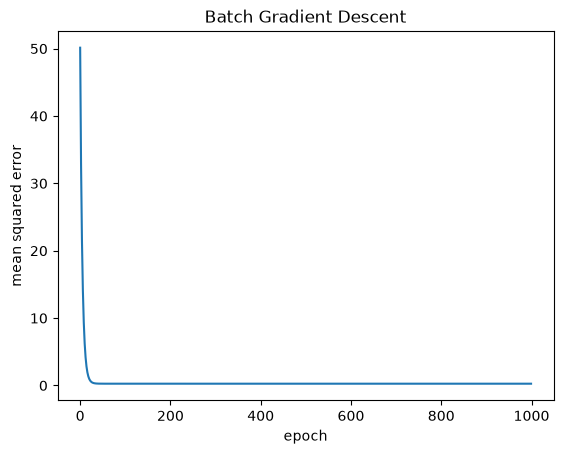

In [24]:
plt.plot(loss_batch)
plt.xlabel('epoch')
plt.ylabel('mean squared error')
plt.title('Batch Gradient Descent')
plt.show()

## Cell 7 — Plot the batch loss curve
This cell plots the mean squared error over training epochs. A decreasing curve indicates that the optimizer is converging toward a good solution.

Expected output: a line plot showing the loss dropping and then flattening.

In [25]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
sk_pred = lr.predict(X_val_s)
sk_rmse = np.sqrt(mean_squared_error(y_val, sk_pred))
print('sklearn RMSE:', round(sk_rmse, 4))
print('sklearn R2:', round(r2_score(y_val, sk_pred), 4))

gd_pred = X_val_s @ w_batch + b_batch
gd_rmse = np.sqrt(mean_squared_error(y_val, gd_pred))
print('batch GD RMSE:', round(gd_rmse, 4))
print('largest coef gap:', round(np.abs(w_batch - lr.coef_).max(), 6))

sklearn RMSE: 0.5125
sklearn R2: 0.7454
batch GD RMSE: 0.5125
largest coef gap: 0.0


## Cell 8 — Compare with scikit-learn
This cell trains a scikit-learn linear regression model and compares its RMSE and R2 score with the hand-written gradient descent model. It validates that the custom implementation is correct.

Expected output: the scikit-learn RMSE and R2, along with the batch gradient descent RMSE and the coefficient gap.

In [26]:
def mini_batch_gd(X, y, epochs=1000, batch_size=32, rate=0.01):
    rng = np.random.default_rng(42)
    w = np.zeros(X.shape[1])
    b = 0.0
    y = np.asarray(y, dtype=float)
    n = len(y)
    losses = []

    for step in range(epochs):
        order = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            error = X[idx] @ w + b - y[idx]
            w = w - rate * (X[idx].T @ error) / len(idx)
            b = b - rate * error.mean()
        losses.append(((X @ w + b - y) ** 2).mean())

    return w, b, losses

w_mini, b_mini, loss_mini = mini_batch_gd(X_train_s, y_train)
mini_rmse = np.sqrt(mean_squared_error(y_val, X_val_s @ w_mini + b_mini))
print('mini-batch RMSE:', round(mini_rmse, 4))
assert abs(mini_rmse - sk_rmse) < 0.3, 'mini-batch RMSE is not within 0.3 of sklearn'
print('Tolerance check PASSED')

mini-batch RMSE: 0.5129
Tolerance check PASSED


## Cell 9 — Implement mini-batch gradient descent
This cell extends the same idea to mini-batches of 32 rows. It updates the parameters more frequently, which makes the training process noisier but cheaper per update.

Expected output: an RMSE close to the reference model and a tolerance check that passes.

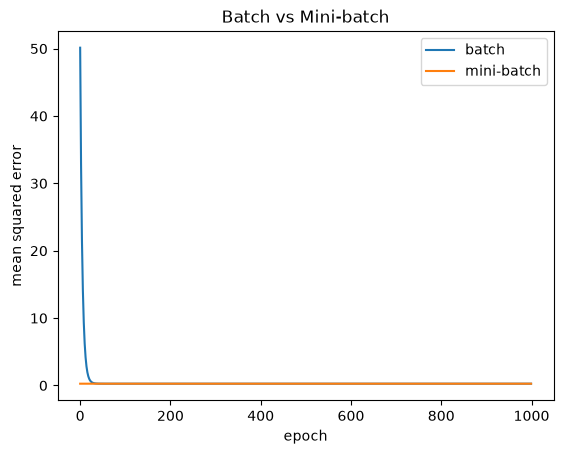

In [27]:
plt.plot(loss_batch, label='batch')
plt.plot(loss_mini, label='mini-batch')
plt.xlabel('epoch')
plt.ylabel('mean squared error')
plt.legend()
plt.title('Batch vs Mini-batch')
plt.show()